# Compare the effect of different dataset initialisations

In [22]:
from typing import List, cast
import json
from pathlib import Path
import matplotlib.pyplot as plt
#locals
import stats
from configs import get_class_list
import preprocess as preproc
from video_dataset import get_wlasl_info, get_labels_path, load_data_from_json

## load data

In [23]:
split_idx = 3 #change for different split
split_options: List[stats.AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
split_name: stats.AVAIL_SPLITS = split_options[split_idx]
print(f'Selected: {split_name}')
classes = get_class_list()
print(f'Num classes: {len(classes)}')

set_options: List[stats.AVAIL_SETS] = ['train', 'test', 'val']
all_sets = {}

tot = 0
for set_name in set_options:
    set_path_info = get_wlasl_info(split_name, set_name)
    set_path = get_labels_path(set_name, set_path_info['labels'], set_path_info['label_suff'])
    all_sets[set_name] = load_data_from_json(set_path, policy="strict")
    print(f'Length of {set_name}: {len(all_sets[set_name])}')
    tot += len(all_sets[set_name])
print(f'Total instances: {tot}')




Selected: asl2000
Num classes: 2000
Length of train: 14295
Length of test: 2879
Length of val: 3918
Total instances: 21092


### reverse preprocessing

In [24]:
for key, item in all_sets.items():
    all_sets[key] = stats.reverse_preproc_format(item, classes)
print(all_sets['test'][0]['gloss'])
print(all_sets['test'][0]['instances'][0])

book
bbox=[60, 37, 197, 230] frame_end=78 frame_start=1 instance_id=15 signer_id=49 source='aslpro' split='test' url='http://www.aslpro.com/main/b/book_medicine.swf' variation_id=0 video_id='07092' label_num=0 label_name='book'


### get stats

In [25]:
from preprocess import WLASLClass
all_stats = {}

for key, item in all_sets.items():
    all_stats[key] = stats.get_per_instance_stats([WLASLClass.model_validate(i) for i in item])
    


In [26]:
setname: stats.AVAIL_SETS = 'train'
metric = 'num_instances'
print(all_stats[setname][classes[-1]][metric])
print(all_stats[setname][classes[-1]].keys())

5
dict_keys(['num_instances', 'length_distribution', 'signers_distribution', 'source_distribution', 'url_distribution', 'variation_distribution'])


In [27]:
print(len(classes))
print(len(all_stats[setname].keys()))
print(list(all_stats[setname].keys()) == classes)
wrong = [(i, k) for i, k in enumerate(all_stats[setname].keys()) if k not in classes]
wrong_idxs = [i for (i, _) in wrong]
cor_wrong = [classes[i] for i in wrong_idxs]
wrong2 = [(i, k) for i, k in enumerate(classes) if k not in all_stats[setname].keys()]
cor_wrong2 = [list(all_stats[setname].keys())[i] for i, _ in wrong2]


print(wrong)
print(cor_wrong)
print(wrong2)
print(cor_wrong2)   

2000
2000
True
[]
[]
[]
[]


In [28]:
with open('./wlasl_class_list.json', 'w') as f:
    json.dump(list(all_stats[setname].keys()), f, indent=4)

/home/luke/Code/SLR/code/stats.py:468: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


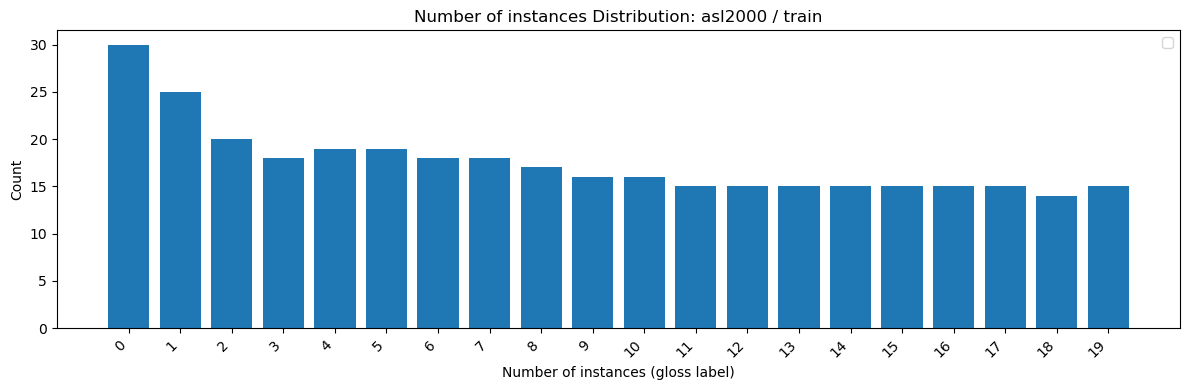

In [29]:
cls_names = list(all_stats[setname].keys())
num_inst_distribution = {cls_names.index(k) : all_stats[setname][k][metric] for k in cls_names[:20]}
stats.plot_distribution(
    stats.HistoGram(num_inst_distribution), 
    set_name=setname,
    split_name=split_name,
    metric='Number of instances',
    unit='gloss label',
    categorical=True,
    bins=20,
    show_nums_on_bars=False

)

In [30]:
num_inst_distribution = {f'{k}_{cls_names.index(k)}' : all_stats[setname][k][metric] for k in cls_names}

def get_n(distribution: dict, n: int, key = lambda x: x[1], start_index: int = 0) -> dict:
    return {k : v for k, v in list(sorted(distribution.items(), key=key))[start_index:start_index+n]}
    
# with open('./debug.json', 'w') as f:
#     json.dump(num_inst_distribution, f, indent=4)
    
    
get_n(num_inst_distribution, 20,start_index=0 )

{'empty_1102': 1,
 'a_1281': 5,
 'a lot_1282': 5,
 'abdomen_1283': 5,
 'able_1284': 5,
 'accountant_1285': 5,
 'action_1286': 5,
 'active_1287': 5,
 'activity_1288': 5,
 'address_1289': 5,
 'affect_1290': 5,
 'afraid_1291': 5,
 'against_1292': 5,
 'agenda_1293': 5,
 'ahead_1294': 5,
 'aim_1295': 5,
 'alcohol_1296': 5,
 'algebra_1297': 5,
 'all day_1298': 5,
 'amazing_1299': 5}

In [31]:
d = {k : v for k, v in zip([chr(i) for i in range(ord('a'), ord('z'))],range(ord('z'), ord('a')-1, -1) )}
e = {k : v for k, v in list(d.items())[:10]}

print(e)
print(get_n(d,10))

{'a': 122, 'b': 121, 'c': 120, 'd': 119, 'e': 118, 'f': 117, 'g': 116, 'h': 115, 'i': 114, 'j': 113}
{'y': 98, 'x': 99, 'w': 100, 'v': 101, 'u': 102, 't': 103, 's': 104, 'r': 105, 'q': 106, 'p': 107}


In [32]:
def get_example_videos

SyntaxError: invalid syntax (3115173611.py, line 1)